In [1]:
import matplotlib.pyplot as plt

# Convolutional Neural Networks

## Reminders about Dense Neural Networks

In [2]:
import tensorflow as tf
import numpy as np

X = np.random.random((100,10))
y = np.random.random((100,))

```python
from keras import models
from keras import Sequential, layers, Input

#### 1. ARCHITECTURE
model = Sequential()
model.add(Input(shape=(10,)))
model.add(layers.Dense(50, activation='relu'))
model.add(layers.Dense(25, activation='relu'))
model.add(layers.Dense(10, activation='relu'))
model.add(layers.Dense(4, activation='softmax')) # What is this model doing?
```

```python
#### 2. COMPILATION

from keras import optimizers

adam_opt = optimizers.Adam(learning_rate=0.01,
                           beta_1=0.9,
                           beta_2=0.999)

# Classification with 2 classes
model.compile(loss='binary_crossentropy',
              optimizer=adam_opt,
              metrics=['accuracy'])

# Classification with more classes
model.compile(loss='categorical_crossentropy',
              optimizer=adam_opt,
              metrics=['accuracy'])

# Regression
model.compile(loss='mse',
              optimizer=adam_opt,
              metrics=['mae'])
```

```python
#### 3. FIT

from keras import callbacks

es = callbacks.EarlyStopping(patience=30, restore_best_weights=True)

model.fit(X, y,
          batch_size=16, # Batch size -too small--> no generalization
          epochs=100,    #            -too large--> slow computations
          validation_split=0.3,
          callbacks=[es],
          verbose=0)
```

🤔 Now, what if my input data is not a vector, but an image?

# 1. Real life applications

### Object Detection

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/object_detection.jpg" width="400">

🚗 Widely used in autonomous cars.

📺 [Nvidia Drive - How AI Helps Autonomous Vehicles See Outside the Box](https://youtu.be/HS1wV9NMLr8?t=15) (1min26)

### Facial Recognition

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/face_recognition.png" width="400">

👤 Facial recognition is more complex than detection, it corresponds to _both_ detecting _and_ recognizing.

### Image Segmentation

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/cell_segmentation.jpg" width="400">

🔬 Widely used in medical imaging.

### Captioning

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/captioning.png" width="800">

Captioning is a complex task because it involves:
- detecting objects/humans
- recognizing them
- outputting descriptive texts!

# 2. Image data preprocessing

## 2.1 Images

Let's start with a reminder of what an image is.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/image_black_and_white.jpg" width="400">

👨🏻‍🏫 A black-and-white picture can be represented by a matrix of size (height, width).

But usually, images are colored.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/image_color.jpg" width="400">

An image is represented by a **tensor** of size (height, width, channels), where the **channels** correspond to the <font color="red">R</font><font color="green">G</font><font color="blue">B</font> colors.

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/image_matrix.png'>

###  ℹ️ Naming conventions ❗️

In <u>Mathematics</u>:
- A **vector** is an array of dimension 1
- A **matrix** is an array of dimension 2
- A **tensor** is an array of dimension 3 or more

In <u>Code</u>, whatever the dimension `ndim`:
- NumPy objects are called `array`
- Tensorflow objects are called `tensor` 

###  ℹ️ Naming conventions ❗️

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/array_tensor_math_vs_code.png" height=200 width=500>

## 2.2 Preprocessing

### Resizing

As in any ML algorithm, your inputs should have the same size. 

<b><u>The choice of image resolution is very important </u></b>❗️

❌ In general, it is useless to train a model with large images (height or width > 256 pixels)

✅ State-of-the-art networks are trained on $(224, 224, 3)$ images.

<b><u>Question</u></b>

Why are large images not that important ❓

If we lower down the image resolution, you can still see the zebra, right?

| Image 1 (1600*1200) | Image 2 (320*240) |
| - | - |
| <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/image_color.jpg" width="400"> | <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/image_color_resized.jpg" width="400"> | 


### Intensity Normalization

👩‍🏫 Keep in mind that neural networks converge faster if the inputs are *somewhat* normalized (typically around -1 and 1), right? 

🔢 For each color (<font color="red">R</font><font color="green">G</font><font color="blue">B</font>), a pixel's intensity ranges from 0 to 255. We should normalize these values.


📚 [tensorflow.keras.layers.Rescaling](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Rescaling)

🧮 You can simply divide all your images' pixels by 255 instead of using the utility provided by Keras.

### Data augmentation

> ***Data augmentation is the process of creating additional data based on your initial dataset.***

👉 For images, it is quite straightforward because if the image label is `zebra` you can easily change your input image a little bit while still showing a zebra. 

👀 Any example of data augmentation?

**Mirror**

|Zebra 1 | Zebra 2|
|- | - |
|<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/image_color_resized.jpg" width="400"> | <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/image_color_resized_mirror.png" width="400">|


**Crop**

| Zebra 1 | Zebra 2 |
| - | - |
| <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/image_color_resized.jpg" width="400"> | <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/image_color_resized_crop.jpg" width="400"> | 


**And many many other image transformations are possible**:

- rotations 
- slight transformation of the colors
- change of the textures
- "photoshop effects": blur, halo, ...
- deformations
- ...

### Data loader

🤔 Can we apply these preprocessing steps to a whole dataset of pictures?

✅ Normalization is quite an easy preprocessing step since it is a division.

❌ For other preprocessing steps, you should _NOT_ apply them to the whole dataset of pictures for computational reasons. If you have a lot of images, they won't fit into your computer's memory.

💡 Images should therefore be loaded on the fly using an image generator.

📚 Don't worry, Keras comes with helpful utilities such as [`tf.keras.preprocessing.image_dataset_from_directory`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory) to perform image loading on the fly.

# 3. Network Architecture


## 3.1 Why are dense networks inappropriate?

Let's consider an input image of size (5, 5) on which there is a red square.


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/square_1_zoom.png" width="600"> 

We could flatten that image to have a vector representation

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/square_1_flatten.png" width="500">

And get an input vector of size 25 that can be fed to a neural network:

```python
from tensorflow.keras.layers import Reshape

model = Sequential()
model.add(Input(shape=(5,5,1)))
model.add(Reshape((5*5*1,))
model.add(Dense(100, activation='relu'))
model.add(Dense(10, activation='softmax'))
```

### Reason #1 not to flatten an image: it generates too many parameters with large images

The first reason why we don't use Dense Neural Networks is that dealing with big pictures would generate a large number of parameters:

In [3]:
from keras import Sequential
from keras import layers, Input

model = Sequential()
model.add(Input(shape=(225,225,3)))
model.add(layers.Reshape((225*225*3,))) # Flattening of a 225*225 image with 3 colors
model.add(layers.Dense(100, activation='relu'))
model.add(layers.Dense(50, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 151875)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │    15,187,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,192,701 (57.96 MB)

 Trainable params: 15,192,701 (57.96 MB)

 Non-trainable params: 0 (0.00 B)

### Reason #2 (most important one): Invariance by translation

**Invariance by translation** means that the information remains the same even if we translate the image.

| Square 1 | Square 2 |
| - | - |
| <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/square_1.png" width="200"> | <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/square_2.png" width="200"> |

We want the prediction based on either of the two images to be the same: there is a red square.

If we compare both resulting vectors, we clearly see that they do not convey the same information.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/square_comparison.png" width="700">

There is no reason for our predictions to be the same for the two input images.

&nbsp;

🤔 What should we do then?

# 3.2 Convolutions

A **convolution** corresponds to a mathematical operation where a **subpart** of the image is **convolved** with a **kernel**. 

<hr>

**`Step 1: Element-wise dot multiplication`** ($\neq$ matrix multiplication).

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/convolution2.png" width="600">

**`Step 2: Convolve`** (i.e. slide) the kernel on different parts of the image to get the output.</u>

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/kernel_1_channel.gif" width="400">

Here, we are using a 3x3 kernel

$$K = \begin{pmatrix} 1& 0& 1\\ 0& 1& 0 \\1& 0& 1\end{pmatrix}$$


❗ **Remark/Question** ❓ 🤔 Where do the values of the kernel come from? 

👍 Excellent question! 

👉 But let's assume (for a few slides) that these values are fixed.

#### What are we actually doing with these kernels? 

Kernels are ways to extract information from images. Let's visualize the output of different convolutional kernels (<a href='https://en.wikipedia.org/wiki/Kernel_(image_processing)'>source</a>):

<div style='display: flex;justify-content: center;'>
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/classic_filters.png" width="360">
</div>

***`Each kernel extracts a particular feature from the image.`***

#### What about images with colors?

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/kernel_3_channels.gif" width="700">

A convolution (and the corresponding kernel) is **applied to each channel, and then summed**, plus an additional bias.



👉 In this example, the set of 3 **kernels** are considered as one **filter**.

👉 A **filter** is composed of as many **kernels** as there are **channels** in the input.


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/kernel_3_channels.gif" width="600">

### One convolution layer

👉 Apply many **filters** to a same input/image. These filters together form a **Convolutional Layer**

<u>Note</u>: it is very similar to **neurons** applied to a same input/vector. These neurons together form a **Dense Layer** as we saw during the two first lessons of Deep Learning.

**Example: 6 filters applied on an image with 3 channels**

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/conv_layer_1.png" width="700">

❓**Question**❓ How many kernels are there overall in this first layer of convolutions ❓

$6$ filters $ \times $ $3$ kernels $/$ filter = $18$ kernels

🚨 **Warning** 🚨 Literature may be confusing because use of the word **kernel** can refer to either:
- each convolution matrix applied to each channel (here, the $3 \times 3$ matrix)
- all the "sub-kernels" applied to all the channels (here, the three $3 \times 3$ matrices)

### Chained convolution layers

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/conv_layer_2.png" width="800">

This is exactly what a Convolutional Neural Network looks like: 

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/conv_network.png" width="800">

⚠️ **Warning** ⚠️ The flattening operation appears only at the end.

More often represented like this

<img src='https://i.stack.imgur.com/Q0xOe.png'>

## Kernel weights

Who decides upon the best kernel weights?

👉 The optimizer! 

<hr>

**`The weights of the kernel are initialized randomly and then learned during model.fit()!`**

$$K = \begin{pmatrix} w_{1, 1}& w_{1, 2}& w_{1, 3}\\ w_{2, 1}& w_{2, 2} & w_{2, 3} \\ w_{3, 1}& w_{3, 2}&  w_{3, 3} \end{pmatrix}$$


👌 This combo randomization + optimization (through forward/backward propagations) in Convolutional Networks is identical to the one in Dense Networks.

❗️ The difference lies in the fact that we perform **convolutions**  instead of **linear regressions**

❓ How many parameters are there for **1 filter** composed of **3 kernels** of **shape $(3,3)$** ❓

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/kernel_3_channels.gif" width="500">

* $3$ `channels` $\times$  $(3 \times 3)$ `kernel` $+ 1$ `bias` = $28$
    * Keep in mind what we need 1 kernel per channel.

❓ How many parameters on these 2 layers supposing all kernels were $(3, 3)$ ❓
<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/conv_layer_2.png" width="500">

In [4]:
layer_1 = 6 * (3 * (3*3)) + 6
layer_2 = 4 * (6 * (3*3)) + 4

print(f"+ layer_1 has {layer_1} parameters")
print(f"+ layer_2 has {layer_2} parameters")
print(f"= which sums up to {layer_1+layer_2} parameters")

+ layer_1 has 168 parameters
+ layer_2 has 220 parameters
= which sums up to 388 parameters


❗ **Important remark** ❗ Where did we use the initial image pixel shape of $255 \times 255$ ❓

👉 The number of parameters in a Convolutional Neural Network does NOT depend on the image shape! 

👉 CNNs have a lot less parameters than dense networks (but require lots of RAM).

## 3.3 Keras syntax

In [6]:
model = Sequential()
model.add(Input(shape=(225, 225, 3)))
model.add(layers.Conv2D(6, kernel_size=(3, 3), activation='relu'))
model.add(layers.Conv2D(4, kernel_size=(3), activation='relu')) # kernel_size = 3 <==> (3, 3)
model.add(layers.Flatten())
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 223, 223, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 221, 221, 4)    │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 195364)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │       195,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195,753 (764.66 KB)

 Trainable params: 195,753 (764.66 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# # Let's load an image of 255 * 255 * 3 channels (color)

# from tensorflow.keras.preprocessing.image import load_img
# url = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/doge.jpg"
# image = np.array(load_img(url))/255

# print(type(image))
# print(image.shape)
# plt.imshow(image);

In [8]:
# # Let's build a dummy batch of 2 images

# batch = np.array([image, image])
# print(batch.shape)

# batch_size, height, width, channels = batch.shape

## 3.4 Intuitions about Kernels 

**Let's do some magic now!**

Let's say that you run your Neural Network, and you obtain the following kernel:

$$K = \begin{pmatrix} 
0 & 0.25 & 0.5 & 0.75 & 1 \\
0 & 0 & 0.25 & 0.5 & 0.75 \\
0 & 0 & 0 & 0.25 & 0.5 \\
0 & 0 & 0 & 0 & 0.25 \\
0 & 0 & 0 & 0 & 0 \\
\end{pmatrix}$$

And this is what it looks like once colored as an image:

In [9]:
following_kernel = [
    [0,0.25,0.5,0.75,1],
    [0,0,0.25,0.5,0.75],
    [0,0,0,0.25,0.5],
    [0,0,0,0,0.25],
    [0,0,0,0,0]
]

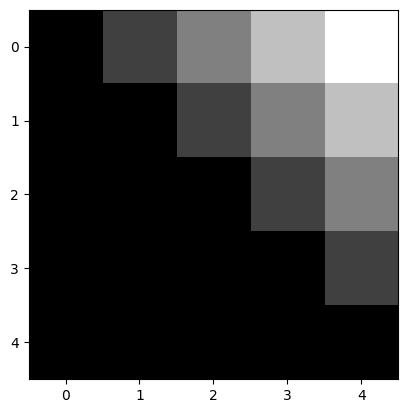

In [10]:
plt.imshow(following_kernel, cmap = "gray")

**In a state-of-the-art CNN, this is what the kernels look like**

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/trained_filters.jpeg" width="370">

- Some kernels specialize in detecting stripes
- Other kernels specialize in detecting patches of color etc...

**Amazing, right?**

We will get a further intuition of what is going on in the exercises.

🔥 You can think of CNNs (and Deep Learning in general) as a ML algorithm where:
- The **feature extraction is done directly by the model**
- You do not have to extract feature manually according to some intuition
- Feature extraction in DL is **optimized for the task at hand**. It is not an independent step


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/ML_vs_DL.png" width="600">



# 4. Convolution hyperparameters

## 4.1 The strides 

❗ **Remark** ❗ In the previous examples, the kernel was applied at all possible positions of the image. But we can imagine the kernel moving by a fixed number of pixels in each direction: the strides

![no_padding_strides.gif](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/no_padding_strides.gif)

**Notes**:
- Bottom: input image in <font color="#146998"><b>blue</b></font> & the (3,3) <font color="grey"><b>grey</b></font> moving square is the kernel
- Top: output image is <font color="#24a097"><b>green</b></font> & the (1, 1) <font color="grey"><b>grey</b></font> square is the result of the convolution

In [11]:
# Default stride = 1
model = Sequential()
model.add(Input(shape=(225, 225, 3)))
model.add(layers.Conv2D(16, (2,2), strides=(1,1), activation="relu"))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 16)   │           208 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208 (832.00 B)

 Trainable params: 208 (832.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Stride = 2
model = Sequential()
model.add(Input(shape=(225, 225, 3)))
model.add(layers.Conv2D(16, (2,2), strides=(2,2), activation="relu"))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 16)   │           208 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208 (832.00 B)

 Trainable params: 208 (832.00 B)

 Non-trainable params: 0 (0.00 B)

## 4.2 The padding

❗ **Remark** ❗ In the previous examples, the kernel was not _less_ applied to the borders of the image. But it is possible to take the borders into account better by virtually adding empty (=0) pixels to them

No padding | Padding
- | - 
<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/no_padding.gif" width="300"> | <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/convolution_same_padding.gif" width="300">

In [13]:
# padding='valid' : no-padding, the output is smaller than the input
model = Sequential()
model.add(Input(shape=(225, 225, 3)))
model.add(layers.Conv2D(16, (2,2), padding='valid', activation="relu"))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 16)   │           208 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208 (832.00 B)

 Trainable params: 208 (832.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# padding='same' : padded with enough empty pixels to get an output of the same size as the input
model = Sequential()
model.add(Input(shape=(225, 225, 3)))
model.add(layers.Conv2D(16, (2,2), padding='same', activation="relu"))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 225, 225, 16)   │           208 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208 (832.00 B)

 Trainable params: 208 (832.00 B)

 Non-trainable params: 0 (0.00 B)

## 4.3 Pooling

💡 After a convolution, practice has shown that it is interesting to reduce the size of the output.

This operation is called **pooling** and you have different options.
 


### Max-pooling layer

```python
model.add(layers.MaxPool2D(pool_size=(2,2)))
```

- It selects the maximum intensity value of the pixels in a given subpart of the image 
- Similar to a kernel, but it is not a convolution operation, just the max of the pixel values.
- Zero params to train

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/pooling_max.png" width="600">

❗ **Remark** ❗ Similar to convolution operations, there are associated notions of "kernel" size, strides and padding.

### Average-pooling layer
```python
model.add(layers.AveragePooling2D(pool_size=(2, 2)))
````

It averages the pixel values in a subpart of the image

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/pooling_average.png" width="700">

✅ **Good practice** ✅ : After each convolution, add a Max-Pooling layer:

In [15]:
model = Sequential()

model.add(Input(shape=(225, 225, 3)))

model.add(layers.Conv2D(16, (2,2), activation="relu"))
model.add(layers.MaxPool2D(pool_size=(2,2)))

model.add(layers.Conv2D(16, (2,2), activation="relu"))
model.add(layers.MaxPool2D(pool_size=(2,2)))

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 16)   │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 111, 111, 16)   │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 55, 55, 16)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,248 (4.88 KB)

 Trainable params: 1,248 (4.88 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Complete model
model = Sequential()
model.add(layers.Conv2D(16, (2,2), input_shape=(225, 225, 3), activation="relu"))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Conv2D(16, (2,2), activation="relu"))
model.add(layers.MaxPool2D(pool_size=(2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(6, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 16)   │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 111, 111, 16)   │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 55, 55, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 48400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │       290,406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291,661 (1.11 MB)

 Trainable params: 291,661 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compare the number of parameters with this dense model!

model2 = Sequential()
model2.add(Input(shape=(225, 225, 3)))
model2.add(layers.Flatten())
model2.add(layers.Dense(16, activation='relu'))
model2.add(layers.Dense(16, activation='relu'))
model2.add(layers.Dense(6, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))

model2.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 151875)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │     2,430,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           102 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,397 (9.27 MB)

 Trainable params: 2,430,397 (9.27 MB)

 Non-trainable params: 0 (0.00 B)

### 💡 Summary

#### ⬛️  Convolutional Layers `layers.Conv2D`

- **`channels`** $\rightarrow$ depth of an image
    - for a colored image, we started with 3 channels (<font color="red">R</font><font color="green">G</font><font color="blue">B</font>)

- **`filters`** $\rightarrow$ operations performed to extract spatial features of an image
    - a filter has several **kernels** (1 kernel per channel)
        - with **padding** 
        - with **strides**


#### ⬛️ Pooling Layers `layers.MaxPooling2D`

- **`pooling`** layers $\rightarrow$ help you reduce the size of the output of a convolutional layer

### 🏛️ It is your responsibility to choose the number of filters and the kernel size for each convolutional layer!

**<u>FILTERS</u>**
- ***Each filter is designed to extract specific information from the input***
    - ✅ Therefore the more filters, the more information
    - ❗️ _But_, the more weights to learn (and possible overfitting)



**<u>KERNEL SIZE</u>**:
- 🔎 ***The kernel size corresponds to the magnifying glass through which you see the image***
    - ❌ $(2,2)$ kernels do not see anything relevant on a 1200 * 800 image 
    - ❌ $(64,64)$ kernels cannot extract meaningful spatial features  on a  128 * 128 image 
    - ✅ $(3,3)$, $(5,5)$ kernels are quite popular to scan 225 * 255 images for example

👍 We studied:
- Image Preprocessing and channels
- Convolutional layers
    - Kernel
    - Strides
    - Padding
- Pooling layers

📆 Let's apply these skills to recognize handwritten digits.
    

🚀 Lastly, we will talk about ***pre-trained models***!

# 5. Real Case: Digits recognition

Handwritten digit recognition is one of the most famous applications of ConvNets.

We can see the different outputs layer after layer.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/digit_recognition.gif" width="600">


Source: http://yann.lecun.com/exdb/lenet/

🕹️ Let's play a game:
- 🔗 Open this [link](https://tensorspace.org/html/playground/lenet.html)

(60000, 28, 28)


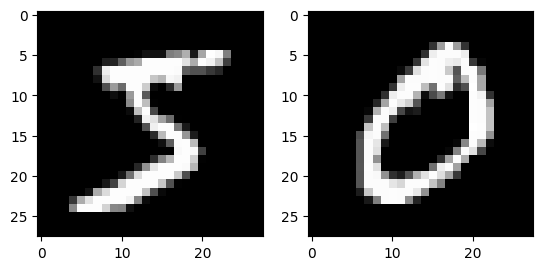

In [19]:
# Let's load the famous MNIST dataset
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train / 255.
X_test = X_test / 255.

print(X_train.shape)
plt.subplot(1,2,1)
plt.imshow(X_train[0], cmap="gray");
plt.subplot(1,2,2)
plt.imshow(X_train[1], cmap="gray");

In [20]:
# Reshape the X to explicitly add a single "color" channel
X_train = X_train.reshape(len(X_train), 28, 28, 1)
X_test = X_test.reshape(len(X_test), 28, 28, 1)
X_train.shape

(60000, 28, 28, 1)

In [21]:
# One Hot Encode our Target for TensorFlow processing
from tensorflow.keras.utils import to_categorical
y_cat_train = to_categorical(y_train, num_classes=10)
y_cat_test = to_categorical(y_test, num_classes=10)
y_cat_train.shape

(60000, 10)

In [22]:
# ——— CNN Version 1: Minimal Network
model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(layers.Conv2D(16, (4,4), activation="relu"))
model.add(layers.Flatten())
model.add(layers.Dense(10, activation='softmax'))

In [23]:
# ——— CNN Version 2: Common Tricks

model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(layers.Conv2D(16, (3,3), padding='same', activation="relu"))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Conv2D(32, (2,2), padding='same', activation="relu"))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(50, activation='relu')) # intermediate layer
model.add(layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 32)     │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 50)             │        78,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,200 (317.19 KB)

 Trainable params: 81,200 (317.19 KB)

 Non-trainable params: 0 (0.00 B)

☝️ It is common to have at least 2 or 3 layers, where
- 🔎 the **kernel size decreases** 📉 
- 📸 the **number of filters increases** (compared to the previous layers) 📈 

In [24]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.fit(X_train, y_cat_train,
          epochs=1,  # Use early stopping in practice
          batch_size=32,
          verbose=1)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8653 - loss: 0.4461


In [25]:
# We now evaluate on the test data
print(model.evaluate(X_test, y_cat_test, verbose=0))

[0.06671654433012009, 0.9797000288963318]


In [27]:
# ——— CNN Version III:

# - Integrate Preprocessing Layers
# - Add Regularization

# Reload raw data
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

model_pipe = Sequential([
    Input(shape=(28, 28, 1)),
    layers.Reshape((28, 28, 1)),
    layers.Rescaling(scale=1./255.),
    layers.Conv2D(16, (3,3), padding='same', activation="relu"),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Conv2D(32, (2,2), padding='same', activation="relu"),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(50, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_pipe.compile(loss='sparse_categorical_crossentropy', # No need to OHE target
              optimizer='adam',
              metrics=['accuracy'])

model_pipe.fit(X_train_raw, y_train_raw,
          epochs=1,  # Use early stopping in practice
          batch_size=32,
          verbose=1)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8338 - loss: 0.5289


In [28]:
## We can now evaluate the model on the test data
print(model_pipe.evaluate(X_test_raw, y_test_raw, verbose=0))

[0.06946524232625961, 0.9786999821662903]


## 5.2 Insights from the model

In [29]:
# Let's focus on the first convolutional layer
layer_1 = model.layers[0]
layer_1

<Conv2D name=conv2d_11, built=True>

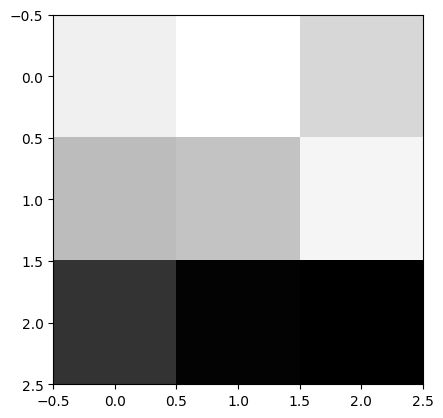

In [30]:
# You can access its 16 kernels. Let's print the last one
plt.imshow(layer_1.weights[0][:,:,:,15], cmap='gray');

In [31]:
# We can also compute the output of the first layer (called it's activation)
# By calling it with a "batch" of images (let's take 10)
batch = X_train[0:10]
activation_1 = layer_1(batch)
activation_1.shape

TensorShape([10, 28, 28, 16])

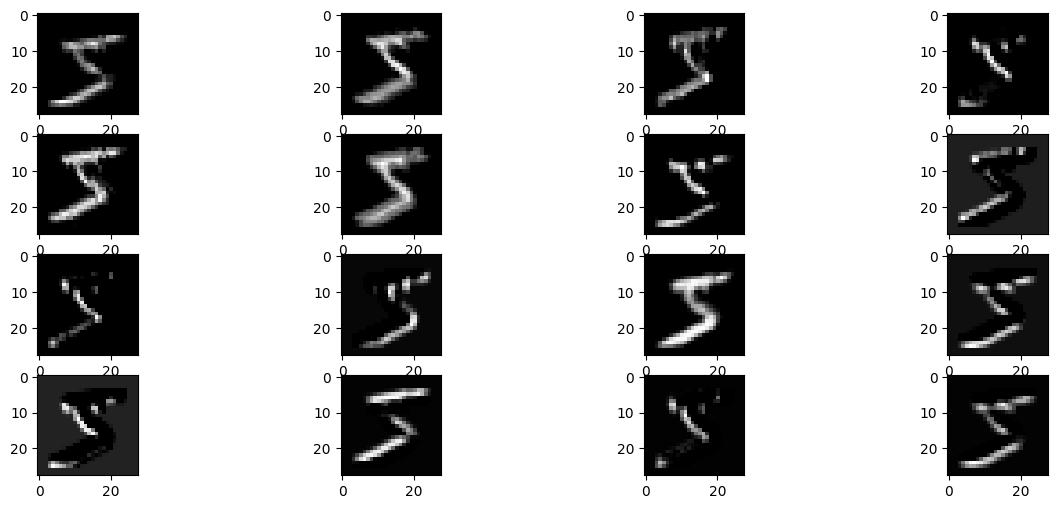

In [32]:
# Let's display all 16 channels' outputs of the first layer, applied to the first image only

fig, axs = plt.subplots(4,4, figsize=(15,6))
for i in range(4):
    for j in range(4):
        feature_map = activation_1[0,:,:,4*i+j]
        axs[i,j].imshow(feature_map, cmap='gray')

☝️ Inspecting "images" as they pass through each layer gives insights about what matters from the "eyes" of the model.

❗️ As they pass through `Conv2D` and `MaxPool2D` layers, these images:
- get smaller and smaller 
- get more and more abstract
- are called an _activation map_ instead

📺 Demo
- 🔗 https://tensorspace.org/html/playground/lenet.html
- 🖇️ https://poloclub.github.io/cnn-explainer/

# 6. Typical architecture & Pre-trained networks

First, let's take a look at the different state-of-the-art architecture out there, designed by scientific labs or industries.

### AlexNet

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/alex_net.png" width="600">

### VGG-16 


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/vgg16.png" width="600">

📺 [Youtube demo](https://www.youtube.com/watch?v=RNnKtNrsrmg)

📚 [Towards Data Science - 10 CNN architectures - illustrated]( https://towardsdatascience.com/illustrated-10-cnn-architectures-95d78ace614d)

🤔 You could reuse a similar architecture for your Computer Vision tasks.

⏳ But learning all the parameters is extremely time-consuming.

😰 And you probably don't have as much data as they did...

## 🚀🚀🚀 Transfer Learning🚀🚀🚀

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/transfer_learning.png">


<center><a href="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/06-DL/transfer_learning.png">🔗 <i>Link to this picture</i></a></center>

- The **`convolutional layers`** are designed to learn some patterns about your images:
    - edges
    - outlines
    - shapes
    - gradients
    - ...
    
👆 If you have a ton of images and train these convolutional layers, the kernels will be "expert" at extracting these patterns. 

🚀 We could load the weights of these convolutional layers without re-training them and 🧊 freeze them!

- From the **SOTA** (state-of-the-art) models, we could simply:
    - ✂️ remove the **`dense layers`** 
        - the hidden layers
        - the predictive layers
        
    - 💈 replace them with layers that are more adapted to our task at hand:
        - some hidden dense layers
        - a classification layer
    - train and update only the weights from these dense layers during the forward/backward propagation 🔥🔥🔥

🎁 Many SOTA (state-of-the-art) architectures are available in Keras, with pre-trained weights.

$\rightarrow$ Using them, we are ***transferring the learnings from pretrained models*** to our own Convolutional Network!


👩🏻‍🎓 See `Deep Learning > CNN > Challenge 04 - Transfer Learning.ipynb` (VGG16)

### Some pretrained models available in `tensorflow.keras.applications`

* 📚 [**VGG16**](https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16)

* 📚 [**VGG19**](https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg19)

* 📚 [**ResNet50**](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet50)

The entire list of pretrained models is available at:
* 📚 [**tensorflow.keras.applications**](https://www.tensorflow.org/api_docs/python/tf/keras/applications)

### 🥋 What is a good strategy to build a ConvNet?

> "***Make the convolutional network open their eyes***"

💡 Keep in mind that SOTA models are trained on $(225,225,3)$ images.

* 🐣 <u>First convolutional layers $\rightarrow$ capture the general spatial features of an image</u>
    - Big kernels $(5,5)$ for example
    - A few filters $32$, $64$, ...
    

* 🕵🏻‍♂️ <u>Last convolutional layers $\rightarrow$ capture the details of an image</u>
    - Smaller kernels $(3,3)$ 
    - More filters $128$, $256$, ...

# Bonus: Google Colab

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/colab.png' width=500>

🔗 ***https://colab.research.google.com/***

📚 [**Le Wagon > Kitt > Library > Tutorials > Introduction to Google Colab**](https://kitt.lewagon.com/knowledge/tutorials/data_google_colab)

📺 Hands-on Google Colab:
1. Load local notebooks
2. Mount Google Drive
3. Activate **GPU runtime**
4. Use Colab freely for 10 hours in a row before it shuts down

# Bibliography

- 📚 [Stanford University - Shervine - CS230 Cheat Sheets](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks)  
- 📺 [Stanford University - CS 231 (15h on Youtube)](https://www.youtube.com/watch?v=OoUX-nOEjG0&list=RDCMUCdKG2JnvPu6mY1NDXYFfN0g)

# 🚀 Your turn!


👩‍🏫 A Convolutional Neural Network (CNN) is a Neural Network designed to analyze and classify images. It consists of:
1. a sequence of { Convolution, MaxPooling } pairs $\rightarrow$ **`spatial features' extraction`**
2. a flattening layer
3. some fully connected layers
4. a last layer that depends on the task $\rightarrow$ **`predictive layer`**

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/03/cnn_classifier.jpeg" width="500">

📺 This video [***Neural Networks 3D simulation***](https://www.youtube.com/watch?v=3JQ3hYko51Y) from Denis Dmitriev will help you visualize the differences between the architecture of a Dense Neural Network versus a CNN.